# ML Model Deployment for Sentiment Analysis of Beauty Product Reviews


### The purpose of this project is to build and deploy a ML model to flag online beauty product reviews as either positive or negative. This model could be integrated on retail websites for customer use to be able to quickly get an overall impression of a product’s 
	

#### Issue Resolution #3

In [1]:
import os

os.listdir()

['amazon_reviews23.csv',
 '.DS_Store',
 'mlruns',
 'mlflow.db',
 'FinalProject.ipynb',
 '.ipynb_checkpoints']

In [2]:
with open("amazon_reviews23.csv", "r", encoding="utf-8", errors="ignore") as f:
    print(f.readline())

,review_text,label



#### Setup #4

In [3]:
import pandas as pd

df = pd.read_csv("amazon_reviews23.csv")

#### Setup #5

In [4]:
df.head()

,Unnamed: 0,review_text,label
0,0,one star bad,0
1,1,three stars okay,1
2,2,missing bottle defective sprayer instead 4 bot...,0
3,3,disappointed little disappointed product case ...,1
4,4,don’t stay began peeling 20 minutes putting on,0


In [5]:
df.shape

(168921, 3)

#### EDA & Data Cleaning

In [6]:
# Remove useless index column
df = df.drop(columns=['Unnamed: 0'])

# Check for missing values
df.isnull().sum()

review_text    73
label           0
dtype: int64

In [7]:
# Check first rows again
df.head()

,review_text,label
0,one star bad,0
1,three stars okay,1
2,missing bottle defective sprayer instead 4 bot...,0
3,disappointed little disappointed product case ...,1
4,don’t stay began peeling 20 minutes putting on,0


In [8]:
# Verify label meanings

df['label'].value_counts()

label
0    56307
1    56307
2    56307
Name: count, dtype: int64

##### Label 0=negative, 1=neutral, 2= positive

In [9]:
# keep only positive and negative
df_binary = df[df['label'] != 1].copy()

# map labels
df_binary['label'] = df_binary['label'].map({0: 0, 2: 1})

df_binary['label'].value_counts()

label
0    56307
1    56307
Name: count, dtype: int64

In [10]:
df_binary.isnull().sum()

review_text    58
label           0
dtype: int64

In [11]:
df_binary = df_binary.dropna(subset=['review_text'])

In [12]:
df_binary.isnull().sum()

review_text    0
label          0
dtype: int64

In [13]:
#text length distribution 

df_binary['text_length'] = df_binary['review_text'].apply(len)

df_binary['text_length'].describe()

count    112556.000000
mean        126.822595
std         150.330206
min           1.000000
25%          45.000000
50%          85.000000
75%         153.000000
max        5462.000000
Name: text_length, dtype: float64

<Axes: >

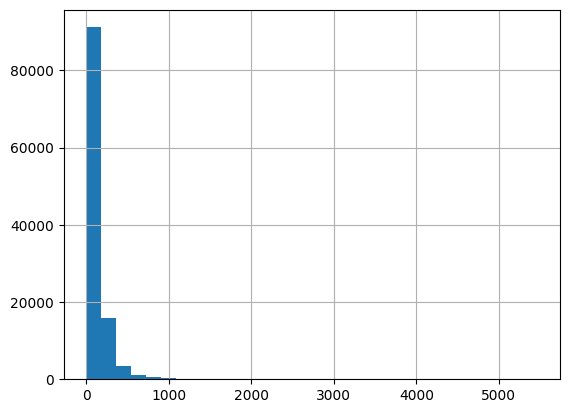

In [14]:
df_binary['text_length'].hist(bins=30)

In [15]:
# Text Cleaning

import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_binary['clean_review'] = df_binary['review_text'].apply(clean_text)

In [16]:
#Feature Selection

X = df_binary['clean_review']
y = df_binary['label']

#### Model Training

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_binary['clean_review'],
    df_binary['label'],
    test_size=0.3,
    random_state=42,
    stratify=df_binary['label']
)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9130215891254775
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     16888
           1       0.91      0.91      0.91     16879

    accuracy                           0.91     33767
   macro avg       0.91      0.91      0.91     33767
weighted avg       0.91      0.91      0.91     33767



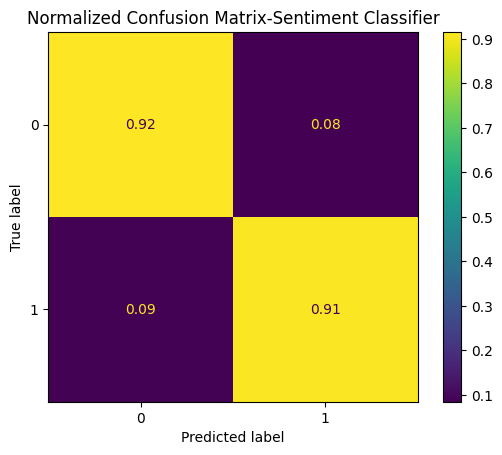

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format=".2f")

plt.title("Normalized Confusion Matrix-Sentiment Classifier")
plt.show()

#### MLflow

In [22]:
!pip install mlflow
import mlflow
import mlflow.sklearn

In [23]:
mlflow.set_tracking_uri("file:/Users/dayanayos/Desktop/CIS 325/finalproject/mlruns")
mlflow.set_experiment("sentiment_analysis")

/opt/miniconda3/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///Users/dayanayos/Desktop/CIS 325/finalproject/mlruns/565107795017231554', creation_time=1780018622887, experiment_id='565107795017231554', last_update_time=1780018622887, lifecycle_stage='active', name='sentiment_analysis', tags={}, workspace='default'>

In [24]:
import os
print(os.getcwd())

/Users/dayanayos/Desktop/CIS 325/finalproject


#### Run 1: Baseline Logistic Regression

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

with mlflow.start_run(run_name="logistic_regression_baseline"):

    # Parameters
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_features", 5000)

    # Train model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)

    # Predictions
    y_pred = model.predict(X_test_vec)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Log model
    mlflow.sklearn.log_model(model, "sentiment_model")

    print("Accuracy:", accuracy)

2026/05/28 21:04:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 21:04:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.9130215891254775


#### Run 2: Improved text features Bigram TF-IDF (adding word pairs)

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
with mlflow.start_run(run_name="bigram_logreg_v1"):

    # TF-IDF with bigrams
    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words='english'
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)

    # Predictions
    y_pred = model.predict(X_test_vec)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Log params
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("vectorizer", "TFIDF")
    mlflow.log_param("ngram_range", "1-2")
    mlflow.log_param("max_features", 5000)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Log model
    mlflow.sklearn.log_model(model, "model")

    print("RUN 2 Accuracy:", accuracy)

2026/05/28 22:42:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 22:42:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RUN 2 Accuracy: 0.9147096277430627


#### Run 3: Naive Bayes Baseline

In [29]:
from sklearn.naive_bayes import MultinomialNB
with mlflow.start_run(run_name="naive_bayes_v1"):

    # TF-IDF (standard unigram setup)
    vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words='english'
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Model
    model = MultinomialNB()
    model.fit(X_train_vec, y_train)

    # Predictions
    y_pred = model.predict(X_test_vec)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Log params
    mlflow.log_param("model", "MultinomialNB")
    mlflow.log_param("vectorizer", "TFIDF")
    mlflow.log_param("max_features", 5000)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Log model
    mlflow.sklearn.log_model(model, "model")

    print("RUN 3 Accuracy:", accuracy)

2026/05/28 21:48:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 21:48:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RUN 3 Accuracy: 0.8960523588118577


#### Save Final Model

In [38]:
#Rerun Final Model to Save

from sklearn.feature_extraction.text import TfidfVectorizer
with mlflow.start_run(run_name="bigram_logreg_v1"):

    # TF-IDF with bigrams
    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words='english'
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)

    # Predictions
    y_pred = model.predict(X_test_vec)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Log params
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("vectorizer", "TFIDF")
    mlflow.log_param("ngram_range", "1-2")
    mlflow.log_param("max_features", 5000)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Log model
    mlflow.sklearn.log_model(model, "model")

2026/05/28 22:44:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 22:44:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [39]:
import pickle

# Save trained model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save vectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [40]:

with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print(type(loaded_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [41]:
with open("vectorizer.pkl", "rb") as f:
    loaded_vec = pickle.load(f)

print(type(loaded_vec))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
